In [ ]:



import numpy as np
import pandas as pd

np.random.seed(42)

samples=2001

house_size = np.random.randint(1,6,size=samples)

num_applicants=np.random.randint(2,16,size=samples)

outdoor_temp = np.random.uniform(-10,41,size=samples)

time_of_day = np.random.randint(0,24,size=samples)

hour_of_day = np.random.randint(0, 24, size=samples)

historical_consumption = np.random.normal(loc=2, scale=1.5, size=samples)


electricity_consumption = historical_consumption + np.random.normal(0,0.4,samples).round(2)



data = pd.DataFrame({
    "household_size":house_size,

    "num_applicants":num_applicants,
    "outdoor_temp":outdoor_temp.round(2),
    "time_of_day":time_of_day,

    "hour_of_day":hour_of_day,

    "historical_consumption":historical_consumption.round(2),
    "electricity_consumption":electricity_consumption.round(2)



}
    )
print(data.head())




   household_size  num_applicants  outdoor_temp  time_of_day  hour_of_day  \
0               4               8         12.21           17            3   
1               5              12          6.94           16           16   
2               3              11          7.43           10            4   
3               5              10         27.69           16           21   
4               5              15          1.39           15           15   

   historical_consumption  electricity_consumption  
0                    2.44                     2.57  
1                    3.01                     2.80  
2                    0.83                     1.03  
3                    2.39                     2.81  
4                    0.58                     0.19  


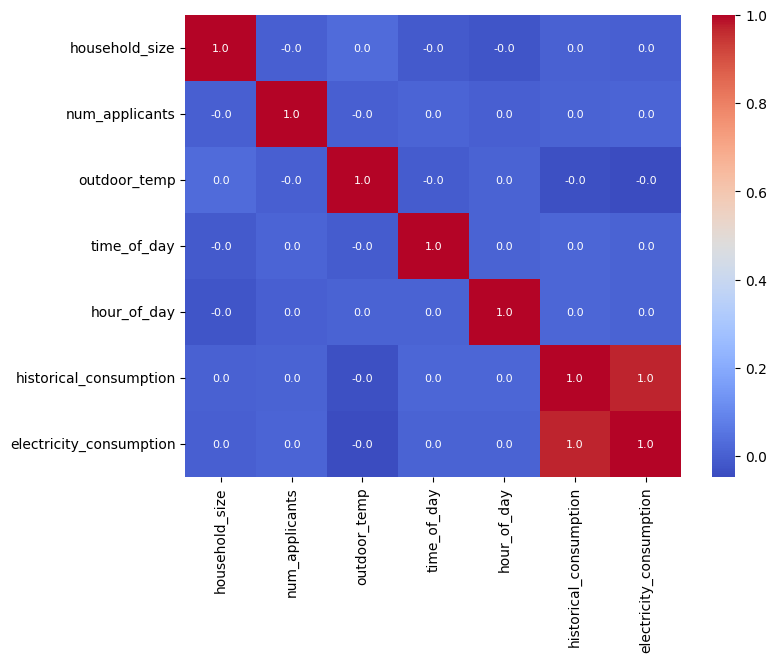

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.1f', annot_kws={"size": 8})
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')


In [ ]:
X = data.iloc[:,1:6].values
y = data.iloc[:,6].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score=True
)

regressor.fit(X_train, y_train)

RandomForestRegressor(oob_score=True, random_state=42)

In [ ]:
print("Out-of-Bag Score:", regressor.oob_score_)

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Out-of-Bag Score: 0.9235092204409894
Mean Squared Error: 0.19358217466334163
R-squared: 0.922167804665634


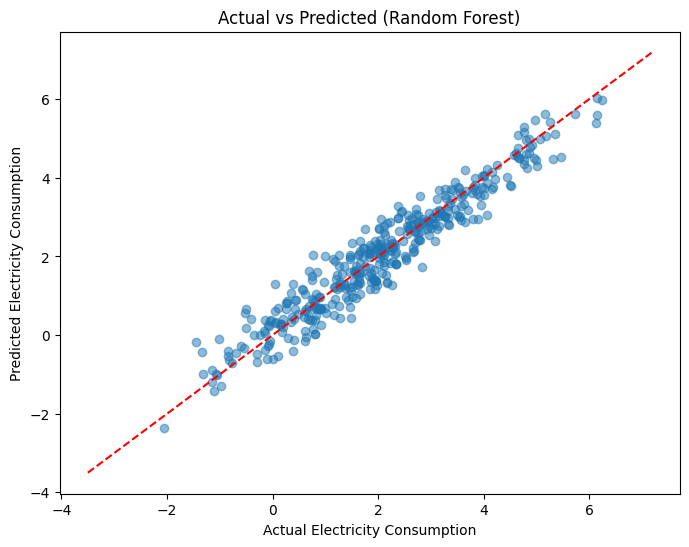

In [ ]:

y_pred = regressor.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Electricity Consumption")
plt.ylabel("Predicted Electricity Consumption")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

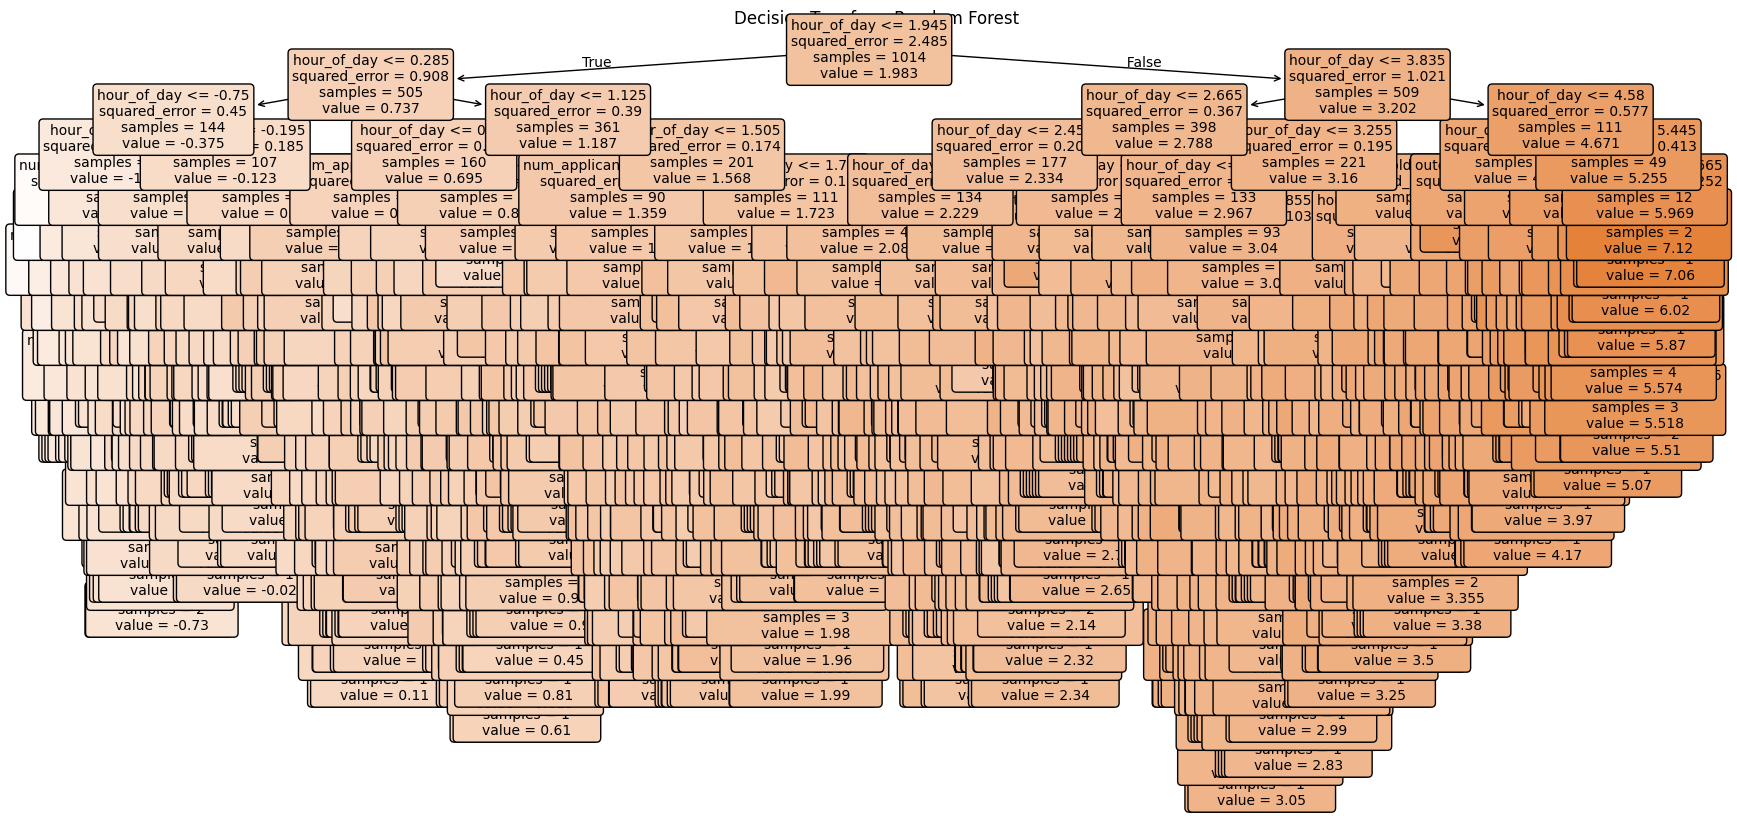

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_to_plot = regressor.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot, feature_names=data.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()

In [ ]:
import joblib

# 保存模型
joblib.dump(regressor, "electricity_model.pkl")

['electricity_model.pkl']